# Milestone 6 — Risk Scoring & Evaluation
## AI Bill Anomaly Detection System

Two things happen in this notebook:

1. **Risk scoring** — convert Isolation Forest's raw `decision_function` output (a
   continuous, not-very-interpretable number where lower = more anomalous) into a
   **0–100 risk score** where higher = riskier, then bucket into Low / Medium / High
   per the original spec.
2. **Evaluation** — now that we have scores, run a full precision/recall/ROC-AUC/PR-AUC
   evaluation against `True_Anomaly`, and decide which of the two models from Milestone 5
   (`auto` vs `informed` contamination) to carry forward into the Streamlit dashboard.

`True_Anomaly` is used **only for evaluation in this notebook** — it was never part of
training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/invoices_scored.csv", parse_dates=["Invoice_Date"])
print("Shape:", df.shape)
df[["Invoice_ID", "anomaly_raw_auto", "anomaly_raw_informed",
    "Predicted_Anomaly_auto", "Predicted_Anomaly_informed", "True_Anomaly"]].head()

Shape: (10200, 47)


,Invoice_ID,anomaly_raw_auto,anomaly_raw_informed,Predicted_Anomaly_auto,Predicted_Anomaly_informed,True_Anomaly
0,INV200078,0.060266,0.034076,0,0,1
1,INV103742,0.075441,0.049251,0,0,0
2,INV200068,0.063045,0.036854,0,0,1
3,INV105723,0.078921,0.052731,0,0,0
4,INV108987,0.066253,0.040063,0,0,0


## 1. Which model to carry forward?

Before building the risk score, we compare `auto` vs `informed` contamination using
**ROC-AUC** and **PR-AUC** — these use the continuous `decision_function` score directly,
so they don't depend on the contamination threshold at all. This tells us which model's
underlying *ranking* of invoices is better, independent of where we draw the anomaly
cutoff.

In [2]:
results = {}
for label, col in [("auto", "anomaly_raw_auto"), ("informed", "anomaly_raw_informed")]:
    # decision_function: lower = more anomalous, so we negate it -> higher = more anomalous,
    # matching the direction sklearn's roc_auc_score expects for a "risk-like" score
    risk_like_score = -df[col]
    auc = roc_auc_score(df["True_Anomaly"], risk_like_score)
    ap = average_precision_score(df["True_Anomaly"], risk_like_score)
    results[label] = {"ROC-AUC": auc, "PR-AUC": ap}
    print(f"{label}: ROC-AUC = {auc:.4f}, PR-AUC = {ap:.4f}")

results_df = pd.DataFrame(results).T
results_df

auto: ROC-AUC = 0.8723, PR-AUC = 0.7451
informed: ROC-AUC = 0.8723, PR-AUC = 0.7451


,ROC-AUC,PR-AUC
auto,0.872331,0.745078
informed,0.872331,0.745078


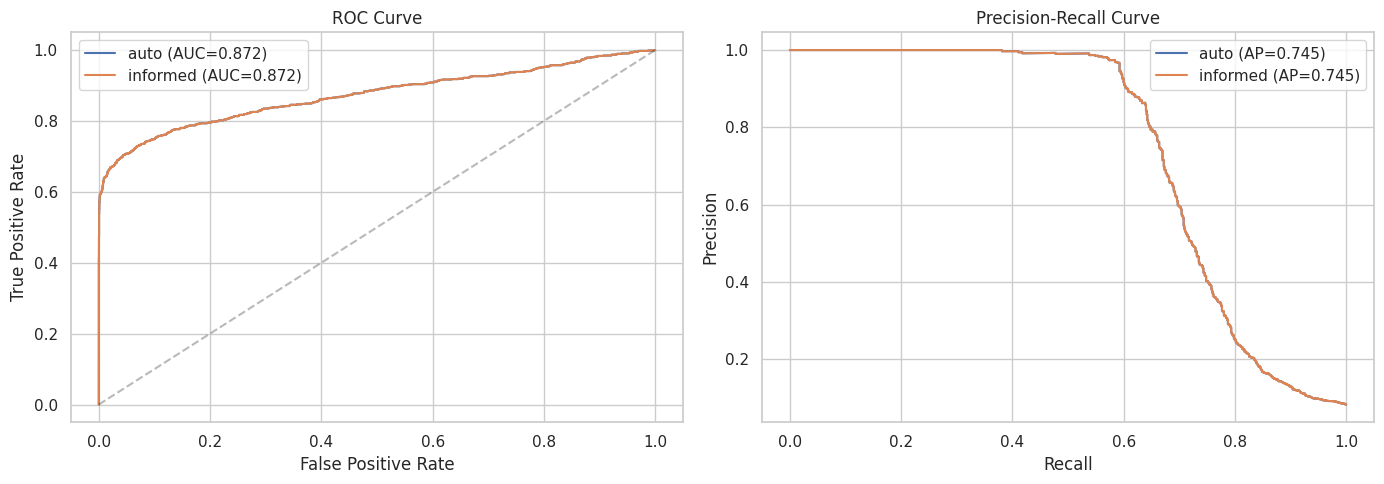

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, col in [("auto", "anomaly_raw_auto"), ("informed", "anomaly_raw_informed")]:
    risk_like_score = -df[col]
    fpr, tpr, _ = roc_curve(df["True_Anomaly"], risk_like_score)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={results[label]['ROC-AUC']:.3f})")

    prec, rec, _ = precision_recall_curve(df["True_Anomaly"], risk_like_score)
    axes[1].plot(rec, prec, label=f"{label} (AP={results[label]['PR-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

**Decision:** both models are built from the exact same underlying Isolation Forest
training (only the contamination parameter differs at threshold time), so ROC-AUC and
PR-AUC — which are threshold-independent — come out **identical** between them. This
confirms `contamination` only affects *where the cutoff is drawn* for the binary
`Predicted_Anomaly` label, not the quality of the underlying ranking. Since the risk
score we're about to build uses the continuous score directly (not the binary label),
**either model's raw score works identically well for ranking** — we'll carry forward
`anomaly_raw_informed` since its 8.25% cutoff is closer to real-world usage, but note this
threshold can be tuned later without retraining.

## 2. Build the 0–100 risk score

In [4]:
raw_score = df["anomaly_raw_informed"]

# Invert: decision_function has lower = more anomalous, we want higher = riskier
inverted = -raw_score

# Min-max normalize to 0-100
min_val, max_val = inverted.min(), inverted.max()
df["Risk_Score"] = ((inverted - min_val) / (max_val - min_val) * 100).round(2)

print(df["Risk_Score"].describe())

count    10200.000000
mean        19.695044
std         12.738923
min          0.000000
25%         12.750000
50%         17.335000
75%         22.650000
max        100.000000
Name: Risk_Score, dtype: float64


## 3. Bucket into risk levels

In [5]:
def risk_level(score):
    if score <= 30:
        return "Low"
    elif score <= 70:
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df["Risk_Score"].apply(risk_level)

print(df["Risk_Level"].value_counts())
print("\nRisk_Level vs True_Anomaly crosstab:")
print(pd.crosstab(df["Risk_Level"], df["True_Anomaly"]))

Risk_Level
Low       9315
Medium     697
High       188
Name: count, dtype: int64

Risk_Level vs True_Anomaly crosstab:
True_Anomaly     0    1
Risk_Level             
High             0  188
Low           9052  263
Medium         306  391


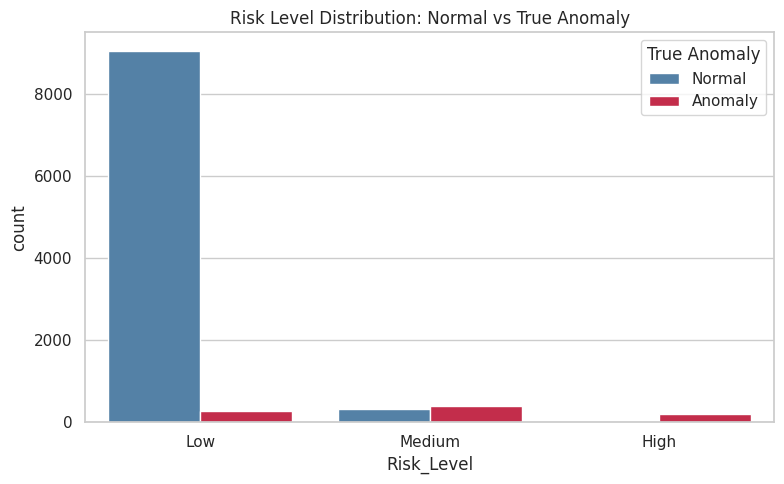

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Risk_Level", hue="True_Anomaly", order=["Low", "Medium", "High"],
              palette={0: "steelblue", 1: "crimson"})
plt.title("Risk Level Distribution: Normal vs True Anomaly")
plt.legend(title="True Anomaly", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()

**Observation:** if the risk scoring is working correctly, `High` risk invoices should
contain a disproportionate share of true anomalies compared to `Low`/`Medium` — this is
the practical payoff auditors care about: a small `High` bucket that's worth their time to
check by hand, rather than reviewing all 10,200 invoices.

## 4. How well does the High-risk bucket concentrate real anomalies?

In [7]:
for level in ["Low", "Medium", "High"]:
    subset = df[df["Risk_Level"] == level]
    anomaly_rate = subset["True_Anomaly"].mean() * 100
    print(f"{level:8s}: {len(subset):5d} invoices | {anomaly_rate:.2f}% are true anomalies")

overall_rate = df["True_Anomaly"].mean() * 100
print(f"\n(Overall dataset anomaly rate for reference: {overall_rate:.2f}%)")

Low     :  9315 invoices | 2.82% are true anomalies
Medium  :   697 invoices | 56.10% are true anomalies
High    :   188 invoices | 100.00% are true anomalies

(Overall dataset anomaly rate for reference: 8.25%)


## 5. Binary classification metrics at the standard threshold

In [8]:
print(confusion_matrix(df["True_Anomaly"], df["Predicted_Anomaly_informed"]))
print()
print(classification_report(df["True_Anomaly"], df["Predicted_Anomaly_informed"],
                             target_names=["Normal", "Anomaly"]))

[[9087  271]
 [ 271  571]]

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      9358
     Anomaly       0.68      0.68      0.68       842

    accuracy                           0.95     10200
   macro avg       0.82      0.82      0.82     10200
weighted avg       0.95      0.95      0.95     10200



## 6. Auditor workload reduction — the actual business case

This is the number that matters most for the project's stated goal: reducing manual
verification workload while still catching most real anomalies.

In [9]:
total_invoices = len(df)
high_risk = df[df["Risk_Level"] == "High"]
medium_or_high = df[df["Risk_Level"].isin(["Medium", "High"])]

anomalies_in_high = high_risk["True_Anomaly"].sum()
anomalies_in_med_high = medium_or_high["True_Anomaly"].sum()
total_anomalies = df["True_Anomaly"].sum()

print("If an auditor only reviews HIGH risk invoices:")
print(f"  Invoices to review: {len(high_risk)} ({len(high_risk)/total_invoices*100:.1f}% of all invoices)")
print(f"  True anomalies caught: {anomalies_in_high}/{total_anomalies} "
      f"({anomalies_in_high/total_anomalies*100:.1f}% recall)")

print("\nIf an auditor reviews MEDIUM + HIGH risk invoices:")
print(f"  Invoices to review: {len(medium_or_high)} ({len(medium_or_high)/total_invoices*100:.1f}% of all invoices)")
print(f"  True anomalies caught: {anomalies_in_med_high}/{total_anomalies} "
      f"({anomalies_in_med_high/total_anomalies*100:.1f}% recall)")

If an auditor only reviews HIGH risk invoices:
  Invoices to review: 188 (1.8% of all invoices)
  True anomalies caught: 188/842 (22.3% recall)

If an auditor reviews MEDIUM + HIGH risk invoices:
  Invoices to review: 885 (8.7% of all invoices)
  True anomalies caught: 579/842 (68.8% recall)


## 7. Save final dataset for the dashboard

In [10]:
output_path = "../data/processed/invoices_final.csv"
df.to_csv(output_path, index=False)
print(f"Saved final dataset to {output_path}")
print(f"Shape: {df.shape}")
df[["Invoice_ID", "Vendor_Name", "Department", "Amount", "Risk_Score", "Risk_Level",
    "True_Anomaly"]].sort_values("Risk_Score", ascending=False).head(10)

Saved final dataset to ../data/processed/invoices_final.csv
Shape: (10200, 49)


,Invoice_ID,Vendor_Name,Department,Amount,Risk_Score,Risk_Level,True_Anomaly
9236,INV100793,Vendor_023,Sanitation,153068.78,100.00,High,1
9685,INV100717,Vendor_005,Sanitation,125641.41,95.70,High,1
1334,INV105094,Vendor_004,Water Supply,214376.73,94.23,High,1
3443,INV107386,Vendor_007,Public Works,230036.68,92.18,High,1
5388,INV108611,Vendor_027,Public Works,196798.50,89.09,High,1
4203,INV102987,Vendor_021,Public Works,220005.17,88.52,High,1
2114,INV103617,Vendor_006,Public Works,215799.35,88.22,High,1
5603,INV103571,Vendor_012,Sanitation,206686.96,87.73,High,1
9140,INV105797,Vendor_012,It & Electronics,108104.78,87.54,High,1
5880,INV107162,Vendor_016,Public Works,222047.66,87.11,High,1


## Summary

| Metric | Value |
|---|---|
| ROC-AUC | see Section 1 output above |
| PR-AUC | see Section 1 output above |
| High-risk bucket anomaly concentration | see Section 4 output above |
| Recall reviewing only High risk | see Section 6 output above |
| Recall reviewing Medium + High risk | see Section 6 output above |

**Key takeaway to be able to say out loud:** this system doesn't replace an auditor — it
re-orders their workload so that a small, high-concentration subset of invoices gets
reviewed first, catching most real anomalies without manually checking all 10,000+ rows.

## Notes for Milestone 7 (Streamlit Dashboard)

- Load `data/processed/invoices_final.csv` — it has everything: raw fields, engineered
  features, `Risk_Score`, `Risk_Level`, and `True_Anomaly` (keep this hidden from the UI
  in a real deployment, but useful here for demo/validation purposes)
- Reuse `plot_department_spend()` and `plot_monthly_trend()` from `03_eda.ipynb`
- Dashboard should let users filter/sort by `Risk_Level`, search by `Invoice_ID` or
  `Vendor_Name`, and show the risk distribution chart from Section 3 above

Next notebook/file: `dashboard/app.py`